<a href="https://colab.research.google.com/github/urashlei/mliot-pyml-2026-hw/blob/main/week02%20/numpy-pandas-eda-hw/numpy_pandas_eda_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [45]:
STUDENT_NAME = "Nguyễn Bảo Tiên"
STUDENT_ID = "K254060779"

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Bảo Tiên (K254060779)


In [46]:
!git clone https://github.com/urashlei/mliot-pyml-2026-hw.git

fatal: destination path 'mliot-pyml-2026-hw' already exists and is not an empty directory.


In [47]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /content/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [48]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [49]:
# TODO N1
# shifted_logits = ...
shifted_logits=logits-np.max(logits, axis=1, keepdims=True)
# exp_logits = ...
exp_logits=np.exp(shifted_logits)
# class_probabilities = ...
class_probabilities=exp_logits/np.sum(exp_logits, axis=1, keepdims=True)
# predicted_classes = ...
predicted_classes=np.argmax(class_probabilities, axis=1)
# confidence_scores = ...
confidence_scores=np.max(class_probabilities, axis=1)

In [50]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [51]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [52]:
# TODO N2
# train_feature_mean = ...
train_feature_mean=np.mean(X_train, axis=0)
# train_feature_std = ...
train_feature_std=np.std(X_train, axis=0)
# X_train_scaled = ...
X_train_scaled=(X_train-train_feature_mean)/train_feature_std
# X_val_scaled = ...
X_val_scaled=(X_val-train_feature_mean)/train_feature_std

In [53]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [54]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [55]:
# TODO N3
# correct_mask = ...
correct_mask=(predicted_classes==true_labels)
# high_confidence_mask = ...
high_confidence_mask=(confidence_scores>=confidence_threshold)
# review_mask = ...
review_mask=~correct_mask|~high_confidence_mask
# review_indices = ...
review_indices=np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [56]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [57]:
# TODO N4
# normalized_batch = ...
normalized_batch=image_batch_uint8.astype(np.float32)/255.0
# augmented_batch = ...
augmented_batch=np.flip(normalized_batch, axis=2).copy()
# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0, 0, 0, 0]=1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho đối tượng gì?
Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports
2. Ký hiệu missing value trong CSV là gì?
iá trị thiếu trong `automobile_raw.csv` được giữ dưới dạng ký hiệu `?`
3. symboling có ý nghĩa gì?
symboling là mức đánh giá rủi ro bảo hiểm của mẫu xe đó. Giá trị nằm trong khoảng từ -3 đến 3, giá trị càng cao (tiến về 3) --> mức độ rủi ro càng lớn, giá trị càng thấp (tiến về -3) --> mức độ rủi ro càng thấp

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [58]:
# TODO D1
# raw_df = ...
raw_df=pd.read_csv(DATA_PATH)
# raw_shape = ...
raw_shape=raw_df.shape
# raw_missing_marker_count = ...
raw_missing_marker_count=(raw_df =='?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [59]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [60]:
# TODO D2
# df_clean = ...
df_clean=raw_df.replace('?', np.nan)
# for column in NUMERIC_COLUMNS:
#     ...
for column in NUMERIC_COLUMNS:
    df_clean[column]=pd.to_numeric(df_clean[column])
# missing_by_column = ...
missing_by_column=df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

- Không nên fill tất cả numeric columns bằng cùng một giá trị vì thứ nhất, mỗi cột có đơn vị và thang đo khác nhau (giá trị 0 có thể hợp lý cho normalized_losses nhưng bất hợp lý với wheel_base or price vì một chiếc xe không thể có kích thước hoặc giá bằng không. Thứ hai, fill hàng loạt làm thay đổi trung bình, phương sai và gây nhiễu cho các mối quan hệ tương quan giữa các feature.
- Với price, lựa chọn drop phù hợp hơn cho bài EDA này vì cột price chỉ có 4 giá trị thiếu, việc loại bỏ 4 mẫu này không gây mất mát dữ liệu quá lớn so với tổng thể, giúp giữ cho tập dữ liệu phân tích được chính xác và tin cậy hơn. Lý do nữa là vì price là biến quan trọng nhất, việc fill giá cho price là rất rủi ro vì giá xe phụ thuộc phức tạp vào rất nhiều yếu tốtố, việc tự ý điền giá trị có thể đưa vào những giả định sai lầm, làm sai lệch kết quả phân tích về mối quan hệ giữa các đặc điểm xe và giá trị thực tế của chúng.
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng:
+ Mất mát thông tin: Nếu chọn phương pháp drop các dòng có missing, mình sẽ mất khoảng 20% dữ liệu của toàn bộ bảng, làm giảm khả năng tổng quát hóa của các kết luận rút ra từ EDA.
+ Bias: Nếu sự thiếu hụt không phải là ngẫu nhiên, việc loại bỏ chúng sẽ khiến mẫu dữ liệu còn lại bị lệch, chỉ đại diện cho một nhóm xe cụ thể.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [61]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [62]:
# TODO D3
# analysis_df = ...
analysis_df=df_clean[AUTO_FEATURES].dropna()
# X_auto = ...
X_auto=analysis_df.to_numpy(dtype=np.float64)
# auto_feature_mean = ...
auto_feature_mean=np.mean(X_auto, axis=0)
# auto_feature_std = ...
auto_feature_std=np.std(X_auto, axis=0)
# X_auto_scaled = ...
X_auto_scaled=(X_auto-auto_feature_mean)/auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [71]:
# TODO D4
# price_index = ...
price_index=AUTO_FEATURES.index('price')
# price_z = ...
price_z=(X_auto[:, price_index]-np.mean(X_auto[:, price_index]))/np.std(X_auto[:, price_index])
# price_outlier_mask = ...
price_outlier_mask=np.abs(price_z)>2
# price_outliers = ...
price_outliers=X_auto[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [72]:
# TODO D5
# engine_price_corr = ...
engine_price_corr=np.corrcoef(X_auto[:, 1], X_auto[:, 5])[1]
# price_by_body_style = ...
price_by_body_style=df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

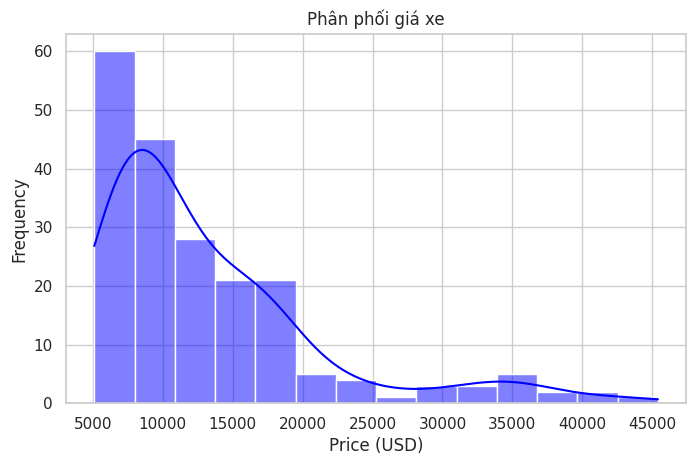

In [73]:
# TODO M2.1: histogram/KDE của price
sns.histplot(data=df_clean, x='price', kde=True, color='blue')
plt.title('Phân phối giá xe')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')

plt.show()

**Nhận xét:** <!-- 1--2 câu -->

- Phân phối price lệch phải: đa số xe có giá dưới $15,000 nhưng có một số xe có giá rất cao (>$30,000) tạo thành đuôi dài bên phải.
- Giá trung bình cao hơn giá trung vị cho thấy ảnh hưởng của các xe đắt tiền làm kéo trung bình lên.


### M2.2 Dataset có cân bằng theo body style không?

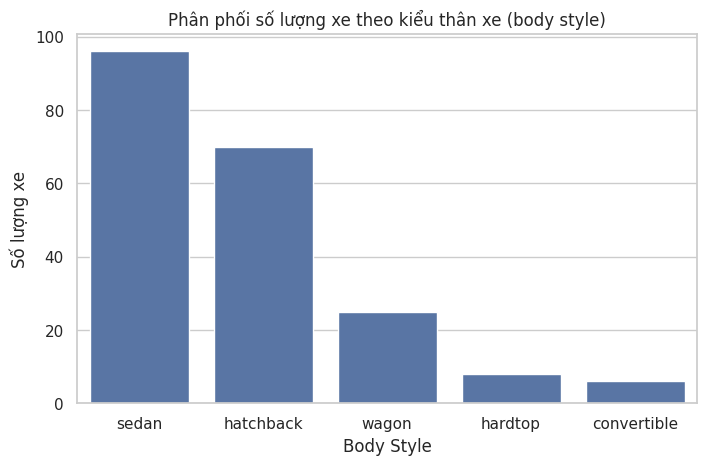

In [75]:
# TODO M2.2: countplot của body_style
sns.countplot(data=df_clean, x='body_style',
              order=df_clean['body_style'].value_counts().index)
plt.title('Phân phối số lượng xe theo kiểu thân xe (body style)')
plt.xlabel('Body Style')
plt.ylabel('Số lượng xe')

plt.show()

**Nhận xét:** <!-- 1--2 câu -->

- Dữ liệu không cân bằng theo body style: sedan chiếm khoảng ~ 90 xe, tiếp theo là hatchback (~70 xe), trong khi các loại như wagon, hardtop, convertible có số lượng rất ít (< 20 xe).
==> Sự mất cân bằng này có thể ảnh hưởng đến các phân tích so sánh sau này (ví dụ: so sánh giá trung bình theo từng loại thân xe) vì các nhóm nhỏ sẽ có độ tin cậy thấp hơn.

## M2.3 Price khác nhau theo body style ra sao?

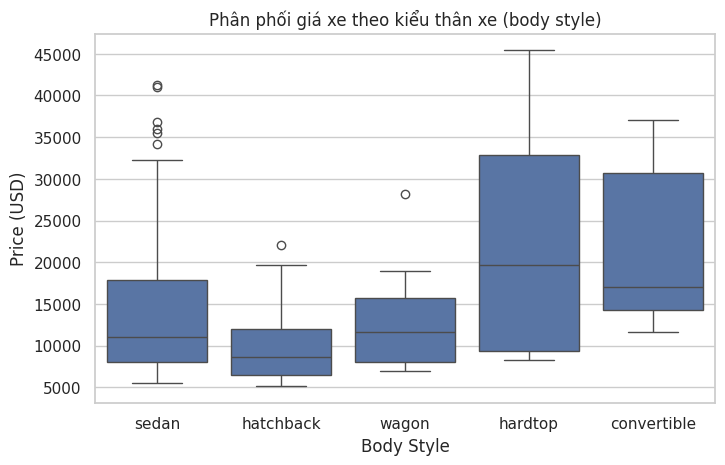

In [77]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price',
            order=['sedan', 'hatchback', 'wagon', 'hardtop', 'convertible'])
plt.title('Phân phối giá xe theo kiểu thân xe (body style)')
plt.xlabel('Body Style')
plt.ylabel('Price (USD)')

plt.show()

**Nhận xét:** <!-- 1--2 câu -->

- Có sự khác biệt rõ rệt về giá giữa các kiểu thân xe: hardtop và convertible có giá trung vị cao nhất (khoảng $17,000–$20,000), trong khi hatchback có giá thấp nhất (trung vị khoảng $7,000).
- Phân phối giá của sedan và wagon khá rộng, cho thấy các dòng xe này có nhiều phân khúc khác nhau, từ bình dân đến cao cấp.

## M2.4 Engine size liên quan thế nào tới price?

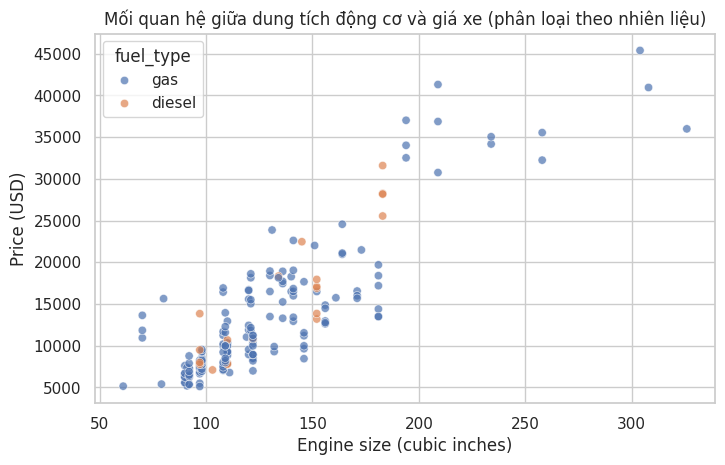

In [78]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', alpha=0.7)
plt.title('Mối quan hệ giữa dung tích động cơ và giá xe (phân loại theo nhiên liệu)')
plt.xlabel('Engine size (cubic inches)')
plt.ylabel('Price (USD)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

- Mối quan hệ tuyến tính dương khá mạnh: engine_size càng lớn thì giá xe càng cao.
- Có một số điểm ngoại lệ: một vài xe có engine_size nhỏ nhưng giá rất cao, thể hiện rằng ngoài engine_size còn có nhiều yếu tố khác ảnh hưởng đến giá.



## M2.5 Các feature numeric tương quan ra sao?

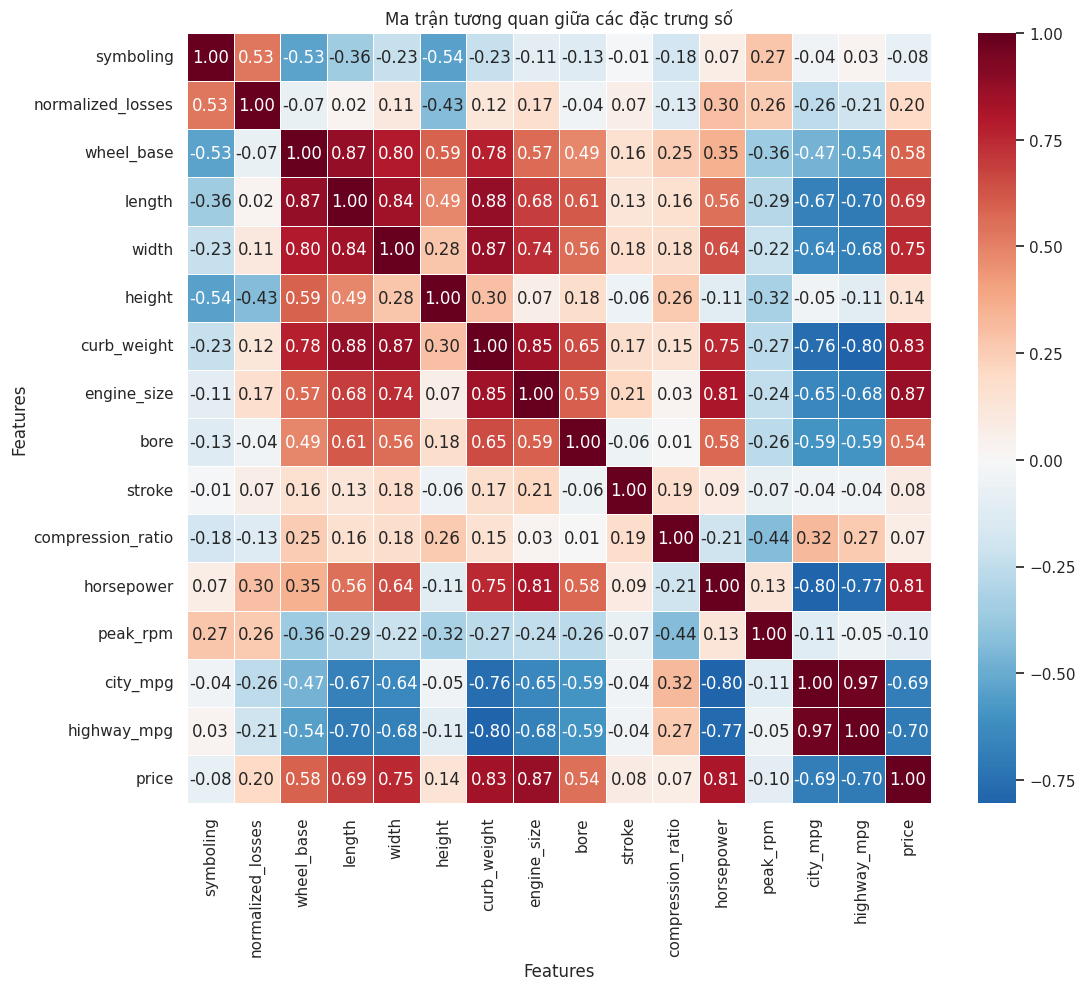

In [81]:
# TODO M2.5: correlation heatmap
corr_matrix=df_clean[NUMERIC_COLUMNS].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title('Ma trận tương quan giữa các đặc trưng số')
plt.xlabel('Features')
plt.ylabel('Features')

plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Biểu đồ Heatmap cho thấy các mối tương quan rất mạnh giữa các nhóm đặc trưng kỹ thuật: giá xe có tương quan thuận cao với engine_size, curb_weight và horsepower, cho thấy kích thước và công suất là các yếu tố chính quyết định giá trị xe. Ngược lại, các chỉ số city_mpg, highway_mpg có tương quan nghịch mạnh với trọng lượng và công suất

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Những hãng sản xuất nào thuộc phân khúc cao cấp với mức giá trung bình cao nhất trong bộ dữ liệu năm 1985?


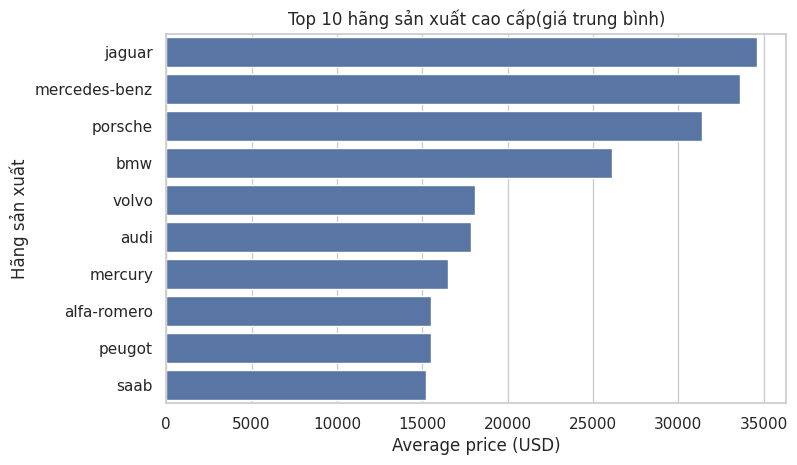

In [82]:
# TODO M2.6: biểu đồ tự chọn
# TODO M2.6: Bar plot giá trung bình theo hãng xe
top_expensive=df_clean.groupby('make')['price'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_expensive.values, y=top_expensive.index)
plt.title('Top 10 hãng sản xuất cao cấp(giá trung bình)')
plt.xlabel('Average price (USD)')
plt.ylabel('Hãng sản xuất')

plt.show()



**Nhận xét:** <!-- 1--2 câu -->

Bar plot cho thấy sự phân hóa thương hiệu rõ rệt trong thị trường ô tô năm 1985; các hãng xe như Jaguar, Mercedes-Benz và Porsche dẫn đầu về mức giá trung bình, vượt xa các hãng xe phổ thông. Sử dụng biểu đồ này giúp xác định phân khúc thị trường của từng hãng, giải thích lý do tại sao một số mẫu xe lại trở thành outliers về giá trong các phân tích trước đó.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

3-5 phát hiện chính có dẫn chứng
- Giá xe có phân phối lệch phải: histogram cho thấy đa số xe có giá dưới 15,000 USD nhưng xuất hiện một số xe có giá trên 30,000 USD, kéo trung bình lên cao hơn trung vị, phản ánh thị trường xe hơi: phân khúc bình dân đông đảo và số ít xe siêu sang.
- Trọng lượng, dung tích động cơ và công suất là các yếu tố dự báo mạnh nhất cho giá: ma trận tương quan cho thấy curb_weight, engine_size và horsepower lần lượt có hệ số tương quan Pearson với price là 0.84, 0.87 và 0.81. Những con số này cho thấy mối quan hệ tuyến tính dương rất chặt chẽ.
- Xe tiết kiệm nhiên liệu thường có giá thấp hơn: city_mpg và highway_mpg có tương quan âm với price (lần lượt –0.69 và –0.65). Điều này có nghĩa là các mẫu xe có mức tiêu hao nhiên liệu thấp (mpg cao) thường thuộc phân khúc giá rẻ hơn, phù hợp với xu hướng xe nhỏ, động cơ nhỏ.

2 hạn chế của dataset
- Missing data ở normalized_losses (41 mẫu thiếu, chiếm ~20%): tỉ lệ missing cao như vậy, việc loại bỏ hàng sẽ giảm kích thước mẫu đáng kể còn việc fill số sẽ có rủi ro làm sai lệch phân phối.
- Dữ liệu thu thập từ năm 1985, kích thước mẫu nhỏ (205 mẫu): thị trường xe hơi đã thay đổi rất nhiều, do đó kết quả EDA có thể không còn phù hợp với thực tế hiện nay (ví dụ: xu hướng xe điện, hybrid). Hơn nữa là số lượng mẫu 205 khi phân chia nhóm (ví dụ theo body_style) dẫn đến một số nhóm có số lượng rất ít (convertible, hardtop), làm giảm độ tin cậy của thống kê.

một ví dụ về correlation không đồng nghĩa causation
- Ma trận tương quan cho thấy engine_size có mối tương quan dương rất mạnh với price (0.87). Tuy nhiên không thể kết luận rằng tăng dung tích động cơ sẽ làm tăng giá. Thực tế là có thể các hãng xe trang bị động cơ lớn cho các dòng xe cao cấp có thêm nhiều tính năng sang trọng và chính những yếu tố này mới thực sự làm tăng giá. engine_size có thể chỉ là một biến đại diện (proxy) cho phân khúc xe cao cấp chứ không phải là nguyên nhân trực tiếp gây ra giá cao.

một câu hỏi nên phân tích tiếp
- Sau khi kiểm soát các yếu tố như engine_size, horsepower và curb_weight, liệu các biến phân loại (make, fuel_type, aspiration, drive_wheels) có còn đóng góp ý nghĩa vào sự khác biệt về giá hay không?
